### 1. Project Introduction

Phishing is one of the most common cyberattacks used to steal sensitive information such as usernames, passwords, banking credentials, and personal data. Attackers create fraudulent websites that closely resemble legitimate websites to deceive users into revealing confidential information.

Traditional phishing detection techniques often struggle to identify newly created or previously unseen phishing websites because they typically rely on predefined rules, blacklists, or known attack patterns.

Machine learning provides a more adaptive approach by learning patterns from historical examples of legitimate and phishing URLs. Rather than relying solely on predefined rules, machine learning algorithms analyse various URL, domain, DNS, SSL, WHOIS, and webpage-related characteristics to classify a website as either legitimate or phishing.

### 1.1 Problem Statement

Phishing attacks continue to be one of the most significant cybersecurity threats, targeting individuals and organisations by impersonating legitimate websites to steal sensitive information. Detecting phishing websites manually is challenging due to the large number of URLs generated every day and the constantly evolving techniques used by attackers.

The objective of this project is to develop a machine learning model capable of automatically classifying a URL as either **Legitimate** or **Phishing** using custom-engineered features extracted from the URL, domain, DNS, SSL, WHOIS, and webpage characteristics.

This is a **supervised binary classification** problem, where the model learns from labelled examples and predicts one of two possible classes:

- **Legitimate (0)** – A genuine and trusted website.
- **Phishing (1)** – A fraudulent website designed to deceive users into revealing sensitive information.

The primary objective is to maximise the model's ability to correctly identify phishing websites while minimising misclassification. To achieve this, multiple machine learning algorithms will be trained, evaluated, and compared using appropriate classification metrics to identify the best-performing model for phishing URL detection.

### 1.2 Dataset Information

The foundation of this project is the **PhiUSIIL Phishing URL Dataset**, obtained from the UCI Machine Learning Repository. The original dataset contains labelled URLs together with a large number of pre-engineered features designed for phishing detection.

Rather than using the provided engineered features directly, only the **URL** and **Label** columns were retained. This decision was made to develop a completely custom feature extraction pipeline capable of extracting meaningful characteristics directly from raw URLs.

By starting with only the raw URLs and their corresponding labels, this project demonstrates the complete workflow of a real-world phishing detection system, where feature extraction is performed before machine learning model training. This approach provides greater flexibility, transparency, and a deeper understanding of the phishing detection process.

### 1.2.1 Original Dataset Objectives

**What was measured?**

The original dataset was designed to investigate which minimal set of features can be used to accurately distinguish phishing websites from legitimate websites.

**Why was it collected?**

With the rapid growth of cybercrime, phishing continues to be one of the most significant cybersecurity threats. Attackers create fraudulent websites that imitate legitimate services to deceive users into revealing sensitive information such as usernames, passwords, and financial details.

The original dataset was collected to support research into cost-effective phishing detection by investigating whether a smaller set of carefully selected features can provide accurate classification performance. Reducing the number of extracted features can lower computational cost while maintaining detection accuracy, making phishing detection systems more practical for real-world deployment.

### 1.2.2 How the Dataset was Generated

Unlike many phishing detection projects that directly use pre-engineered features, this project generates a completely new machine learning dataset through a custom feature extraction pipeline.

The original PhiUSIIL dataset was used only as a source of labelled URLs. During preprocessing, only the **URL** and **Label** columns were retained, while all existing engineered features were discarded. For each URL, multiple custom Python modules extracted lexical, domain, DNS, SSL, WHOIS, and webpage-based characteristics.

The feature extraction pipeline consists of three specialised modules:

- **Basic Features** – Extracts lexical characteristics directly from the URL, such as URL length, domain length, path length, special characters, and HTTPS usage.
- **Domain Features** – Extracts domain-related characteristics, including subdomains, suspicious keywords, brand impersonation indicators, top-level domain analysis, URL entropy, and redirect masking.
- **Internet Features** – Collects internet-based information, including SSL certificates, WHOIS records, domain age, DNS records, HTTP responses, webpage content, HTML forms, password fields, and external hyperlink statistics.

The extracted features from each module are combined with the original class label to generate a new dataset named **Phishing_Features.csv**. This generated dataset forms the foundation for all subsequent stages of the project, including data preprocessing, exploratory data analysis, feature selection, machine learning model development, and model evaluation.

**What do the instances in this dataset represent?**

Each instance represents a unique URL together with the features extracted from that URL and its associated webpage.

**Does the dataset contain missing values?**

Yes. During feature extraction, unavailable information was intentionally stored as the placeholder value **"None"** rather than as missing values (`NaN`). This design preserves information about unavailable internet-based features and allows different preprocessing strategies to be applied later in the notebook.

### 1.3 Project Structure

To improve maintainability, readability, and scalability, the phishing URL detection system was organised into multiple Python modules, with each module responsible for a specific stage of the feature extraction process. This modular architecture follows good software engineering practices by separating feature extraction, dataset generation, and machine learning into independent components.

```text
Phishing_URL_Detector/
│
├── Phishing_URL_Dataset.csv      # Original dataset
├── extraction.py                 # Main feature extraction pipeline
├── basic_features.py             # Lexical feature extraction
├── dmn_features.py               # Domain feature extraction
├── internet_features.py          # SSL, WHOIS, DNS and HTTP feature extraction
├── Phishing_Features.csv         # Generated feature dataset
├── phishing_url_detector.ipynb   # Machine learning notebook
└── README.md                     # Project documentation
```

Each module has a clearly defined responsibility. The original dataset serves as the source of labelled URLs, the feature extraction modules generate meaningful characteristics for each URL, and the generated dataset is subsequently used to preprocess the data, perform exploratory analysis, select informative features, and train multiple machine learning models.

### 1.4 Feature Categories

The custom feature extraction pipeline generates features from multiple sources to capture different characteristics of phishing websites. Rather than relying on a single source of information, the extracted features are grouped into logical categories, providing a comprehensive representation of each URL.

| Feature Category | Description | Example Features |
|------------------|-------------|------------------|
| **Lexical Features** | Features extracted directly from the URL without requiring internet access. | URL length, domain length, path length, number of dots, digits, special characters, HTTPS usage, IP address detection |
| **Domain Features** | Features describing the structure and characteristics of the domain name. | Subdomain count, suspicious keywords, brand impersonation indicators, URL entropy, top-level domain analysis, redirect masking |
| **Internet Features** | Features requiring communication with external services. | SSL certificate information, WHOIS records, domain age, DNS records, HTTP status codes |
| **Webpage Features** | Features extracted by analysing the webpage content. | HTML forms, password fields, suspicious page titles, external hyperlink ratio |

By combining lexical, domain, internet, and webpage-based features, the generated dataset provides a comprehensive representation of each URL, enabling machine learning models to distinguish legitimate websites from phishing websites more effectively.

### 1.5 Understanding URL Structure

Before extracting features from a URL, it is important to understand its structure. A **URL (Uniform Resource Locator)** is the address used to locate resources on the Internet. Every URL consists of multiple components, and many of the features used in phishing detection are derived directly from these components.

For example, features such as URL length, domain name, subdomains, path length, query parameters, and the communication protocol (HTTP or HTTPS) are obtained by analysing different parts of a URL.

Understanding these components makes it easier to understand how features are engineered and why they are useful for distinguishing legitimate websites from phishing websites.

---

### 1.5.1 Example URL

```text
https://login.secure-paypal.com.account-verification.xyz:8080/security/update/login.php?id=10293&session=abc123#section2
```

The following sections break this URL into its individual components.

---

### 1.5.2 Scheme (Protocol)

```text
https://
```

The **scheme**, also known as the **protocol**, specifies how communication takes place between the client (web browser) and the web server.

Common protocols include:

| Protocol | Description |
|----------|-------------|
| HTTP | HyperText Transfer Protocol (unencrypted) |
| HTTPS | HyperText Transfer Protocol Secure (encrypted using SSL/TLS) |
| FTP | File Transfer Protocol |

Although HTTPS encrypts communication, attackers can also obtain valid SSL certificates. Therefore, HTTPS alone should not be considered evidence that a website is legitimate.

---

### 1.5.3 Host

```text
login.secure-paypal.com.account-verification.xyz
```

The **host** identifies the server hosting the website and consists of two main parts:

- Registered domain
- Subdomains

---

### 1.5.4 Registered Domain

```text
account-verification.xyz
```

The **registered domain** is the domain that has been officially registered.

It consists of:

- **Domain Name:** `account-verification`
- **Top-Level Domain (TLD):** `xyz`

Common Top-Level Domains (TLDs) include:

- `.com`
- `.org`
- `.net`
- `.edu`
- `.gov`

---

### 1.5.5 Subdomains

```text
login.secure-paypal.com
```

Everything before the registered domain is considered the **subdomain**.

Subdomains are commonly used to organise different sections or services of a website.

For example:

```text
mail.google.com
```

- Subdomain: `mail`
- Registered Domain: `google.com`

Phishing websites often exploit long or misleading subdomains to impersonate trusted organisations.

For example:

```text
login.paypal.com.fake-domain.xyz
```

Although the URL appears to contain **paypal.com**, the actual registered domain is **fake-domain.xyz**.

---

### 1.5.6 Port (Optional)

```text
:8080
```

The **port number** specifies which network service on the server should receive the request.

Common ports include:

| Port | Service |
|------|----------|
| 80 | HTTP |
| 443 | HTTPS |
| 21 | FTP |
| 22 | SSH |
| 8080 | Alternative HTTP |

If no port is specified, the browser automatically uses the default port associated with the selected protocol.

---

### 1.5.7 Path

```text
/security/update/login.php
```

The **path** specifies the location of the requested resource on the web server.

It may refer to:

- A webpage
- An image
- A document
- A script
- An API endpoint

Unusually long or deeply nested paths may sometimes indicate suspicious behaviour.

---

### 1.5.8 Query Parameters

```text
?id=10293&session=abc123
```

Query parameters provide additional information to the web server.

Each parameter consists of a **key-value pair**.

For this example:

| Parameter | Value |
|-----------|-------|
| id | 10293 |
| session | abc123 |

Multiple parameters are separated using the `&` character.

Large numbers of parameters or unusually long query strings can sometimes indicate suspicious URLs.

---

### 1.5.9 Fragment (Optional)

```text
#section2
```

A **fragment** identifies a specific location within a webpage.

Fragments are processed by the browser and are generally **not transmitted to the web server**.

---

### 1.5.10 Complete URL Breakdown

```text
https://login.secure-paypal.com.account-verification.xyz:8080/security/update/login.php?id=10293&session=abc123#section2

│
├── Scheme (Protocol)
│   https
│
├── Host
│   ├── Subdomains
│   │   login.secure-paypal.com
│   │
│   ├── Registered Domain
│   │   account-verification.xyz
│   │
│   └── Top-Level Domain
│       xyz
│
├── Port
│   8080
│
├── Path
│   /security/update/login.php
│
├── Query Parameters
│   id=10293
│   session=abc123
│
└── Fragment
    section2
```

---

### 1.5.11 Why Understanding URL Structure is Important

Many of the features extracted in this project are derived directly from different components of a URL. Understanding the structure of a URL makes it easier to understand how each feature is generated and why it can help distinguish legitimate websites from phishing websites.

| URL Component | Example Features |
|--------------|------------------|
| Entire URL | URL length, number of digits, number of special characters |
| Scheme | HTTPS usage |
| Registered Domain | Domain length, suspicious keywords, Top-Level Domain |
| Subdomains | Number of subdomains |
| Path | Path length, file extension |
| Query Parameters | Number of parameters, query length |

---

### 1.6 Loading the Dataset

Before building machine learning models, the dataset must first be loaded into the notebook. The generated dataset (**Phishing_Features.csv**) is stored in **CSV (Comma-Separated Values)** format, where each row represents a website and each column represents a feature extracted during the custom feature engineering process.

The dataset is loaded using the **pandas** library and its `read_csv()` function, which imports the data into a **DataFrame**. A DataFrame provides a structured tabular representation that supports efficient data exploration, preprocessing, visualisation, and machine learning.

When loading a CSV file, several aspects should be verified to ensure the data is imported correctly:

- The header row is correctly recognised as the column names.
- The delimiter matches the format used in the file.
- Placeholder values (such as `"None"`) are preserved correctly instead of being automatically converted to missing values (`NaN`).

These checks help ensure that the dataset is loaded accurately before performing data quality assessment and preprocessing.

In [325]:
# Install required libraries
%pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [326]:
import pandas as pd

# Load the generated phishing feature dataset
filename = "Phishing_Features.csv"

# Read the dataset while preserving placeholder values
# such as "None" instead of automatically converting
# them to missing values (NaN).
df = pd.read_csv(
    filename,
    keep_default_na=False
)

### 1.7 Checking the Dataset

After loading the dataset, it is good practice to inspect the first few rows before performing any analysis. This helps verify that the dataset has been loaded correctly and provides an initial understanding of its structure and contents.

The `head()` function displays the first five rows of a DataFrame by default. It is commonly used to confirm that the column names have been imported correctly, the feature values appear under the appropriate columns, and the data has been loaded as expected.

The following code displays the first five rows of the dataset for an initial inspection.

In [327]:
# Display the First Five Rows
df.head()

,URL,url_length,domain_length,path_length,query_length,param_count,has_equal,has_ampersand,query_ratio,dots,...,domain_age_days,new_domain,dns_exists,dns_ip_count,http_status,title_suspicious,form_count,has_password_field,external_link_ratio,label
0,https://www.southbankmosaics.com,32,24,0,0,0,0,0,0.0,2,...,2353,0,1,1,200,0,1,0,0.027777777777777776,1
1,https://www.uni-mainz.de,24,16,0,0,0,0,0,0.0,2,...,None,None,1,1,200,0,0,0,1.0,1
2,https://www.voicefmradio.co.uk,30,22,0,0,0,0,0,0.0,3,...,5931,0,1,4,200,0,0,0,0.22115384615384615,1
3,https://www.sfnmjournal.com,27,19,0,0,0,0,0,0.0,2,...,7218,0,1,2,403,None,None,None,None,1
4,https://www.rewildingargentina.org,34,26,0,0,0,0,0,0.0,2,...,2553,0,1,2,200,0,1,0,0.7647058823529411,1


### Understanding the Output

The output displays the first five rows of the dataset, providing an initial preview of the data. Each row represents a single website, while each column represents a feature extracted during the custom feature engineering process or the corresponding class label.

Reviewing the first few rows helps verify that:

- The dataset has been loaded successfully.
- The column names have been imported correctly.
- The feature values appear under the correct columns.
- The data is in the expected format before proceeding with further analysis.

### 1.8 Dataset Dimensions

Before performing data quality assessment, exploratory data analysis, or building machine learning models, it is useful to determine the size of the dataset.

The size of a dataset is described by its **dimensions**, which consist of:

- **Rows** – The number of observations (URLs).
- **Columns** – The number of variables, including the extracted features and the target label.

Pandas provides the `shape` attribute to return the dimensions of a DataFrame as a tuple in the following format:

```text
(number_of_rows, number_of_columns)
```

Checking the dataset dimensions helps verify that the dataset has been loaded correctly and provides an overview of its size before further analysis.

In [328]:
# Display the dimensions of the dataset
print("Dataset Dimensions (Rows, Columns):", df.shape)

Dataset Dimensions (Rows, Columns): (235795, 58)


### Understanding the Output

The output shows that the dataset contains **235,795 rows** and **58 columns**.

- **235,795 rows** represent individual website instances (URLs).
- **58 columns** include the extracted features generated by the custom feature engineering pipeline together with the target label.

This indicates that the dataset is sufficiently large for training and evaluating machine learning models. Verifying the dataset dimensions also confirms that the dataset has been loaded successfully before proceeding to data quality assessment and preprocessing.

### 1.9 Dataset Overview

After inspecting the first few rows and the dataset dimensions, the next step is to examine the overall structure of the dataset.

Pandas provides the `info()` method, which displays a concise summary of a DataFrame, including:

- The total number of rows and columns.
- The column names.
- The data type of each column.
- The number of non-null entries in each column.
- The memory usage of the dataset.

This information helps verify that the dataset has been loaded correctly, confirms whether each feature has the expected data type, and identifies any columns containing missing values (`NaN`).

Since this dataset was loaded using `keep_default_na=False`, placeholder values such as `"None"` are preserved as string values rather than being automatically converted to missing values (`NaN`). Consequently, these placeholder values are counted as valid entries in the dataset summary.

In [329]:
# Display a summary of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 58 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   URL                  235795 non-null  str    
 1   url_length           235795 non-null  int64  
 2   domain_length        235795 non-null  int64  
 3   path_length          235795 non-null  int64  
 4   query_length         235795 non-null  int64  
 5   param_count          235795 non-null  int64  
 6   has_equal            235795 non-null  int64  
 7   has_ampersand        235795 non-null  int64  
 8   query_ratio          235795 non-null  float64
 9   dots                 235795 non-null  int64  
 10  hyphens              235795 non-null  int64  
 11  underscores          235795 non-null  int64  
 12  letters_ratio        235795 non-null  float64
 13  digit_ratio          235795 non-null  float64
 14  special_ratio        235795 non-null  float64
 15  https                235795 

### Understanding the Output

The output provides a summary of the dataset, including the total number of observations, the number of features, the data type of each column, the number of non-null values, and the overall memory usage.

From the summary, we can observe that:

- The dataset contains **235,795 observations** and **58 columns**.
- All **58 columns** contain **235,795 non-null values**, indicating that no values have been loaded as missing (`NaN`).
- The dataset contains a mixture of numerical and categorical features:
  - **37 integer (`int64`) features**
  - **5 floating-point (`float64`) features**
  - **16 string (`str`) features**
- The total memory required to store the dataset is approximately **104.3 MB**.

Although every column appears to be fully populated, this does **not** necessarily mean that every value contains useful information. Several categorical features intentionally use the placeholder value **"None"** to represent unavailable information. Because the dataset was loaded using `keep_default_na=False`, these placeholders are preserved as string values rather than being converted to missing values (`NaN`), and are therefore included in the non-null counts.

This summary confirms that the dataset has been loaded correctly and provides an overview of its structure before performing a detailed data quality assessment.

### 2. Data Quality Assessment

Before developing machine learning models, it is essential to evaluate the quality of the dataset and apply the necessary preprocessing steps. Real-world datasets often contain duplicate records, inconsistent data types, placeholder values, and features that provide little useful information. If these issues are not addressed, they can reduce model performance and lead to unreliable predictions.

The dataset used in this project was generated through a custom feature extraction pipeline and contains lexical, domain, DNS, SSL, WHOIS, and webpage-based features. Before these features can be used for machine learning, their quality and suitability must be assessed.

This chapter consists of three main stages:

- **Data Quality Assessment** – Evaluate the dataset by analysing placeholder values, duplicate URLs, duplicate records, data types, and feature quality.
- **Data Preprocessing** – Clean and transform the dataset by removing unnecessary data, converting feature data types, encoding categorical variables, and standardising numerical features.
- **Feature Preparation** – Produce a consistent and machine learning-ready dataset that will be used for feature selection, exploratory data analysis, and model development.

Performing these steps ensures that the dataset is accurate, consistent, and suitable for building reliable machine learning models.

### 2.1 Placeholder Value Analysis

Before performing data preprocessing, it is important to understand how unavailable information is represented in the dataset.

Unlike many datasets that store unavailable information as missing values (`NaN`), this dataset intentionally uses the placeholder value **"None"**. This design was adopted during feature extraction because several internet-based features, such as SSL certificates, WHOIS records, DNS information, and webpage content, may legitimately be unavailable for some URLs.

Since the dataset was loaded using `keep_default_na=False`, these placeholder values are preserved as string values instead of being automatically converted into missing values (`NaN`). As a result, they are treated as valid entries in the dataset summary.

The following analysis calculates both the **number** and **percentage** of placeholder values in each feature. This helps identify features that contain large amounts of unavailable information and supports informed preprocessing decisions in later stages of the notebook.

In [330]:
# Analyse the occurrence of the placeholder value "None"
# in each feature of the dataset.

placeholder_summary = pd.DataFrame({
    "Placeholder Count": (df == "None").sum(),
    "Placeholder Percentage (%)": ((df == "None").mean() * 100).round(2)
})

# Keep only the features that contain placeholder values
# and sort them from highest to lowest occurrence.

placeholder_summary = (
    placeholder_summary[placeholder_summary["Placeholder Count"] > 0]
    .sort_values("Placeholder Count", ascending=False)
)

# Display the placeholder summary.

placeholder_summary

,Placeholder Count,Placeholder Percentage (%)
ssl_issuer_known,235795,100.00
external_link_ratio,107370,45.54
title_suspicious,107358,45.53
form_count,107358,45.53
has_password_field,107358,45.53
domain_age_days,96391,40.88
new_domain,96391,40.88
http_status,62232,26.39
has_ssl,62135,26.35
dns_exists,48234,20.46


### Understanding the Output

The output summarises both the **number** and **percentage** of placeholder values (`"None"`) contained in each feature.

The analysis shows that several internet-based features contain unavailable information because the required data could not be retrieved during feature extraction. This is expected, as information such as SSL certificates, WHOIS records, DNS records, and webpage content may not always be available.

The most notable observations are:

- **ssl_issuer_known** contains placeholder values for **100%** of the observations, indicating that SSL issuer information was not successfully extracted for any URL. This feature will be investigated further during the **Feature Quality Assessment** stage.
- **external_link_ratio**, **title_suspicious**, **form_count**, and **has_password_field** each contain placeholder values for approximately **45.5%** of the dataset, reflecting cases where webpage content could not be accessed.
- **domain_age_days** and **new_domain** contain placeholder values for approximately **40.9%** of the observations because WHOIS information was unavailable.
- **has_ssl** and **http_status** contain placeholder values for approximately **26%** of the dataset, while **dns_exists** and **dns_ip_count** each contain approximately **20.5%** placeholder values due to unavailable network information.

These results indicate that placeholder values primarily affect internet-based features and should be handled carefully during preprocessing rather than being treated as conventional missing values (`NaN`).

### 2.2 Duplicate Analysis

Duplicate records can reduce the quality of a dataset by introducing redundant information and potentially biasing machine learning models. In this project, two types of duplicates are analysed:

- **Duplicate URLs** – The same URL appearing multiple times in the dataset.
- **Duplicate Rows** – Entire records that are identical across every feature.

These two types of duplicates have different implications. Duplicate URLs may occur if the same website appears multiple times in the original dataset, while duplicate rows indicate that every feature value is identical.

Before preprocessing, it is important to quantify both types of duplicates. This helps determine whether duplicate observations should be removed to improve the quality and representativeness of the dataset.

In [331]:
# Analyse duplicate URLs and completely duplicated rows.

duplicate_summary = pd.DataFrame({
    "Metric": ["Duplicate URLs", "Duplicate Rows"],
    "Count": [
        df["URL"].duplicated().sum(),
        df.duplicated().sum()
    ]
})

# Calculate the percentage of duplicates relative
# to the total number of observations.

duplicate_summary["Percentage (%)"] = (
    duplicate_summary["Count"] / len(df) * 100
).round(2)

# Display the duplicate analysis summary.

duplicate_summary

,Metric,Count,Percentage (%)
0,Duplicate URLs,425,0.18
1,Duplicate Rows,187,0.08


### Understanding the Output

The output summarises the number and percentage of duplicate URLs and completely duplicated records present in the dataset.

The analysis shows that:

- **425 duplicate URLs (0.18%)** are present, indicating that a small number of websites appear more than once in the dataset.
- **187 duplicate rows (0.08%)** are present, meaning that every feature value is identical for those records.

Although the proportion of duplicates is relatively small, duplicate URLs can cause certain websites to be overrepresented during model training. To ensure that each website contributes only one observation, duplicate URLs will be removed during preprocessing while retaining the first occurrence of each unique URL.

The duplicate row analysis provides an additional integrity check and confirms that fully duplicated records are also present in the dataset.

### 2.2.1 Remove Duplicate URLs

The duplicate analysis identified a small number of repeated URLs within the dataset. Although the proportion of duplicate URLs is low, retaining multiple occurrences of the same website may lead to certain URLs being overrepresented during model training.

To ensure that each website contributes only one observation, duplicate URLs are removed while retaining the first occurrence of each unique URL. Since duplicate rows are also duplicate URLs, removing duplicate URLs automatically eliminates fully duplicated records associated with those repeated URLs.


In [332]:
# Remove duplicate URLs while
# keeping the first occurrence.

df = (
    df.drop_duplicates(
        subset="URL",
        keep="first"
    )
    .reset_index(drop=True)
)

# Display the updated dataset size.

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Verify that no duplicate URLs remain.

print(f"\nRemaining Duplicate URLs: {df['URL'].duplicated().sum()}")

# Verify that no completely duplicated rows remain.
print(f"Remaining Duplicate Rows: {df.duplicated().sum()}")

Rows: 235370
Columns: 58

Remaining Duplicate URLs: 0
Remaining Duplicate Rows: 0



### 2.3 Feature Quality Assessment

Not all extracted features contribute useful information for machine learning. Some features may contain the same value for every observation, while others may have one value that dominates the dataset. Such features provide little or no discriminative information and may unnecessarily increase model complexity.

This section evaluates the quality of each feature by identifying:

- **Constant features**, which contain only a single unique value.
- **Near-constant features**, where one value dominates the majority of observations.

Identifying these features helps determine whether they should be removed before model training, resulting in a cleaner and more informative dataset.

In [333]:
# Analyse the quality of every feature.

feature_quality = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Most Frequent Value": df.mode().iloc[0],
    "Most Frequent Count": df.apply(lambda column: column.value_counts().iloc[0])
})

feature_quality["Most Frequent Percentage (%)"] = (
    feature_quality["Most Frequent Count"] / len(df) * 100
).round(2)

feature_quality = feature_quality.sort_values(
    "Most Frequent Percentage (%)",
    ascending=False
)

feature_quality

,Unique Values,Most Frequent Value,Most Frequent Count,Most Frequent Percentage (%)
ssl_issuer_known,1,None,235370,100.00
has_ip,2,0.0,234733,99.73
url_encoded,2,0.0,234487,99.62
has_double_slash,2,0.0,234439,99.60
repeated_hyphen,2,0.0,234261,99.53
has_at,2,0.0,233864,99.36
redirect_masking,2,0.0,233864,99.36
has_at_misuse,2,0.0,233874,99.36
very_deep_subdomain,2,0.0,233534,99.22
repeated_special,9,1.0,233175,99.07


### Understanding the Output

The output summarises the quality of every feature by reporting the number of unique values, the most frequently occurring value, its frequency, and the percentage of observations containing that value.

The analysis reveals several important characteristics of the dataset:

- **ssl_issuer_known** contains only a single unique value (`None`) across all observations, making it a **constant feature**. Since it provides no information for distinguishing between phishing and legitimate URLs, it will be removed during preprocessing.
- Several features, including **has_ip**, **url_encoded**, **has_double_slash**, and **has_at**, are **near-constant**, with one value occurring in more than 95% of the observations. Although these features contain little variation, they are retained because the rare occurrences may still provide valuable information for phishing detection. Their usefulness will be evaluated later using feature selection techniques.
- Features such as **URL**, **domain**, **registered_domain**, **subdomain**, and **tld** contain a large number of unique values. This high cardinality is expected because these features describe website-specific information and naturally exhibit substantial diversity.

Overall, the feature quality assessment confirms that the dataset is suitable for further preprocessing, with only constant features requiring immediate removal before model development.

### 3 Data Preprocessing

The previous sections evaluated the quality of the dataset and identified issues that could affect machine learning performance. This section applies the necessary preprocessing steps to prepare the dataset for feature selection and model development.

The preprocessing process consists of the following operations:

- Removing constant features that provide no predictive information.
- Removing duplicate URLs while retaining the first occurrence of each unique URL.
- Removing any remaining duplicate records.
- Converting numerical features to appropriate data types.
- Replacing placeholder values where required.
- Encoding categorical features.
- Standardising numerical features.

Each preprocessing step is performed sequentially to ensure that the dataset is clean, consistent, and suitable for machine learning.

### 3.1 Remove Constant Features

Constant features contain only a single unique value across the entire dataset and therefore provide no information for distinguishing between phishing and legitimate URLs. Since these features have zero variance, they cannot contribute to model learning and unnecessarily increase the dimensionality of the dataset.

Based on the feature quality assessment, any constant features identified are removed before applying the remaining preprocessing steps.

In [334]:
# Identify features that contain only one unique value.

constant_features = df.columns[df.nunique() == 1].tolist()

# Remove the constant features from the dataset.

df = df.drop(columns=constant_features)

# Display the removed features.

pd.DataFrame({
    "Removed Constant Features": constant_features
})

,Removed Constant Features
0,ssl_issuer_known


### Understanding the Output

The output lists all constant features that were removed from the dataset.

A constant feature has the same value for every observation and therefore provides no useful information for distinguishing between different classes. Removing these features reduces the dimensionality of the dataset without losing any predictive information.

Based on the previous analysis, **ssl_issuer_known** is expected to be removed because every observation contains the placeholder value **"None"**. The remaining features retain sufficient variation to support subsequent preprocessing and machine learning tasks.

### 3.2 Remove High-Cardinality Identifier Features

The dataset contains several textual features, including **URL**, **subdomain**, **domain**, **registered_domain**, and **tld**, that have a very large number of unique values. These features primarily act as identifiers rather than generalisable predictors, as many values occur only once or a few times within the dataset.

During feature extraction, the information contained within these textual features has already been transformed into meaningful numerical and categorical features, such as URL length, domain length, subdomain count, suspicious keywords, spoofed brand indicators, path depth, and entropy. Retaining the original identifier features would therefore introduce unnecessary dimensionality while providing little additional predictive information.

To reduce dataset complexity and minimise the risk of overfitting, these high-cardinality identifier features are removed before further preprocessing.

In [335]:
# Remove high-cardinality identifier features.

high_cardinality_features = [
    "URL",
    "subdomain",
    "domain",
    "registered_domain",
    "tld"
]

df = df.drop(columns=high_cardinality_features)

# Display the removed features.
pd.DataFrame({
    "Removed High-Cardinality Features": high_cardinality_features
})

,Removed High-Cardinality Features
0,URL
1,subdomain
2,domain
3,registered_domain
4,tld


### Understanding the Output

The output lists the high-cardinality identifier features that were removed from the dataset.

These features contain a large number of unique values and primarily identify individual websites rather than describing general characteristics associated with phishing. Since their information has already been captured through engineered features generated during the feature extraction process, retaining them would unnecessarily increase the dimensionality of the dataset and may encourage machine learning models to memorise specific websites instead of learning general phishing patterns.

Removing these features simplifies the dataset while preserving the engineered features that provide meaningful information for feature selection and model development.

### 3.3 Classify String-Based Features for Preprocessing

After removing the constant and high-cardinality identifier features, the remaining dataset is examined to identify features that require additional preprocessing.

Most features are already stored using appropriate numerical data types and can be used directly during feature selection and model development. However, a small number of features are currently stored as strings because they contain the placeholder value `"None"`.

These string-based features do not all represent the same type of information. Some represent numerical measurements that have been stored as text, while others represent categorical values. Consequently, they require different preprocessing strategies.

To ensure that each feature is handled appropriately, the string-based features are classified into the following groups:

- **Numerical features stored as strings** – These features contain numerical values but are stored as text because unavailable information is represented by the placeholder value `"None"`. Before they can be used for analysis, `"None"` will be replaced with `NaN`, after which the features will be converted to appropriate numerical data types.

- **Categorical features containing `"None"`** – These features represent categorical information, where `"None"` indicates that the corresponding information could not be obtained during feature extraction. Rather than treating `"None"` as a missing value, it will be preserved as a separate category during encoding.

Classifying these string-based features establishes a clear preprocessing strategy and ensures that each feature is processed according to its underlying meaning rather than its current storage format.

In [336]:
# Identify all features stored as string data types.

string_features = (
    df.select_dtypes(include=["object", "string"])
    .columns
    .tolist()
)

print("String-Based Features:")
print(string_features)

String-Based Features:
['has_ssl', 'domain_age_days', 'new_domain', 'dns_exists', 'dns_ip_count', 'http_status', 'title_suspicious', 'form_count', 'has_password_field', 'external_link_ratio']


In [337]:
# Summarise the identified string-based features.

feature_summary = []

for feature in string_features:

    unique_values = sorted(df[feature].dropna().unique())

    if len(unique_values) <= 10:
        values = ", ".join(map(str, unique_values))
    else:
        values = "Numeric values, None"

    feature_summary.append({
        "Feature": feature,
        "Data Type": str(df[feature].dtype),
        "Unique Values": df[feature].nunique(),
        "Observed Values": values
    })

feature_summary = pd.DataFrame(feature_summary)

feature_summary

,Feature,Data Type,Unique Values,Observed Values
0,has_ssl,str,3,"0, 1, None"
1,domain_age_days,str,12476,"Numeric values, None"
2,new_domain,str,3,"0, 1, None"
3,dns_exists,str,2,"1, None"
4,dns_ip_count,str,20,"Numeric values, None"
5,http_status,str,75,"Numeric values, None"
6,title_suspicious,str,3,"0, 1, None"
7,form_count,str,142,"Numeric values, None"
8,has_password_field,str,3,"0, 1, None"
9,external_link_ratio,str,18575,"Numeric values, None"


### Understanding the Output

The table summarises the characteristics of all features currently stored as string data types. Although all ten features share the same storage format, their observed values indicate that they represent two different types of information.

Five features (**has_ssl**, **new_domain**, **dns_exists**, **title_suspicious**, and **has_password_field**) contain only a small number of discrete values, such as `0`, `1`, and `"None"`. These values represent distinct states rather than numerical measurements, indicating that these features are categorical.

The remaining five features (**domain_age_days**, **dns_ip_count**, **http_status**, **form_count**, and **external_link_ratio**) contain numerical measurements or counts. However, they are currently stored as strings because unavailable values are represented by the placeholder value `"None"`. These features therefore require conversion to appropriate numerical data types after the placeholder values have been replaced with `NaN`.

Based on these observed characteristics, the string-based features are classified into separate numerical and categorical groups so that each group can be preprocessed using the most appropriate technique before feature selection and model development.

In [338]:
# Classify the identified string-based features into
# numerical and categorical groups for preprocessing.

numerical_string_features = [
    "domain_age_days",
    "dns_ip_count",
    "http_status",
    "form_count",
    "external_link_ratio"
]

categorical_string_features = [
    feature
    for feature in string_features
    if feature not in numerical_string_features
]

# Display the classified feature groups.

print(f"Total String-Based Features: {len(string_features)}")

print(f"\nNumerical Features Stored as Strings ({len(numerical_string_features)}):")
print(numerical_string_features)

print(f"\nCategorical Features Stored as Strings ({len(categorical_string_features)}):")
print(categorical_string_features)

Total String-Based Features: 10

Numerical Features Stored as Strings (5):
['domain_age_days', 'dns_ip_count', 'http_status', 'form_count', 'external_link_ratio']

Categorical Features Stored as Strings (5):
['has_ssl', 'new_domain', 'dns_exists', 'title_suspicious', 'has_password_field']


### 3.4 Replace Placeholder Values in Numerical Features

The previous section identified five numerical features that are currently stored as strings because unavailable information is represented by the placeholder value `"None"`. Before these features can be converted to appropriate numerical data types, the placeholder values must first be replaced with the standard missing value representation (`NaN`).

Only the numerical string features are processed during this step. For the categorical features, `"None"` represents a meaningful category indicating that the corresponding information could not be obtained during feature extraction. Therefore, these values are retained and will be preserved during categorical encoding.

In [339]:
# Replace the placeholder value "None" with NaN
# in the numerical string features.

df[numerical_string_features] = (
    df[numerical_string_features]
    .replace("None", pd.NA)
)

# Display the number of missing values
# created after replacing the placeholder.

display(
    df[numerical_string_features]
    .isna()
    .sum()
    .rename("Missing Values")
    .to_frame()
)

,Missing Values
domain_age_days,96097
dns_ip_count,48128
http_status,62119
form_count,106967
external_link_ratio,106979


### Understanding the Output

The output shows the number of missing values created after replacing the placeholder value `"None"` with `NaN` in the numerical string features.

The results indicate that all five numerical features contain unavailable information collected during feature extraction. The highest number of missing values is observed in **external_link_ratio** (107,370) and **form_count** (107,358), followed by **domain_age_days** (96,391), **http_status** (62,232), and **dns_ip_count** (48,234).

Replacing `"None"` with `NaN` converts these placeholder values into the standard missing value representation used by pandas. This enables the missing values to be identified and handled consistently during subsequent preprocessing steps, such as data type conversion and missing value imputation.

The categorical string features are not modified during this step because the value `"None"` represents a valid category indicating that the corresponding information could not be obtained during feature extraction, rather than missing numerical information.

### 3.5 Convert Numerical String Features to Numeric Data Types

After replacing the placeholder value `"None"` with `NaN`, the numerical string features can now be converted to appropriate numerical data types. This conversion ensures that the features are recognised as numerical variables rather than text, allowing them to be used for statistical analysis, feature selection, missing value imputation, and machine learning algorithms.

The conversion is performed using `pd.to_numeric()`, which safely converts valid numerical values while preserving any missing values as `NaN`.

In [340]:
# Convert the numerical string features
# from string to numeric data types.

df[numerical_string_features] = (
    df[numerical_string_features]
    .apply(pd.to_numeric)
)

# Display the data types of the converted features.

display(
    df[numerical_string_features]
    .dtypes
    .rename("Data Type")
    .to_frame()
)

,Data Type
domain_age_days,float64
dns_ip_count,float64
http_status,float64
form_count,float64
external_link_ratio,float64


### 3.6 Identify Numerical and Categorical Features

Following data type conversion, all remaining features can now be grouped into their final preprocessing categories based on their data types. Numerical features include all integer and floating-point variables, while categorical features consist of variables stored as object data types.

Creating these feature lists provides a consistent reference for the remaining preprocessing pipeline. The numerical feature list will be used for numerical preprocessing techniques, whereas the categorical feature list will be used during categorical encoding. These lists also simplify subsequent feature selection and model development by clearly separating the two feature types.

In [341]:
# Create the list of numerical features.

numerical_features = [
    feature
    for feature in df.select_dtypes(include=["number"]).columns
    if feature != "label"
]

# Create the list of categorical features.

categorical_features = (
    df.select_dtypes(include=["object", "string"])
    .columns
    .tolist()
)

print(f"Number of numerical features: {len(numerical_features)}")
print(f"Number of categorical features: {len(categorical_features)}")

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Number of numerical features: 46
Number of categorical features: 5

Numerical Features:
['url_length', 'domain_length', 'path_length', 'query_length', 'param_count', 'has_equal', 'has_ampersand', 'query_ratio', 'dots', 'hyphens', 'underscores', 'letters_ratio', 'digit_ratio', 'special_ratio', 'https', 'has_at', 'has_ip', 'has_double_slash', 'repeated_hyphen', 'repeated_special', 'has_html', 'hostname_length', 'path_segments', 'complex_path', 'subdomain_count', 'many_subdomains', 'is_suspicious_tld', 'is_trusted_tld', 'tld_unknown', 'suspicious_words', 'has_suspicious_word', 'spoofed_brand', 'deep_subdomain', 'very_deep_subdomain', 'php_page', 'long_path', 'path_depth', 'url_encoded', 'entropy', 'redirect_masking', 'has_at_misuse', 'domain_age_days', 'dns_ip_count', 'http_status', 'form_count', 'external_link_ratio']

Categorical Features:
['has_ssl', 'new_domain', 'dns_exists', 'title_suspicious', 'has_password_field']


### Understanding the Output

The output confirms that the dataset now contains **46 numerical features** and **5 categorical features**, with the target variable (`label`) excluded from both lists. This indicates that all predictor variables have been successfully grouped according to their data types.

The numerical feature list consists of integer and floating-point variables that will be used for numerical preprocessing techniques and feature selection. The categorical feature list contains the remaining object-based variables that require categorical encoding before they can be used by machine learning algorithms.

Creating these feature lists establishes a consistent structure for the remaining preprocessing pipeline, allowing subsequent operations to be applied to the appropriate subset of features while keeping the target variable separate from the input features.

### 3.7 Examine Categorical Feature Values

Before applying categorical encoding, it is important to examine the unique values present in each categorical feature. This helps identify the number of categories, detect inconsistent values, and determine an appropriate encoding strategy for each feature.

Understanding the distribution of categorical values ensures that the selected encoding method accurately represents the information contained within each feature while avoiding unnecessary preprocessing.

In [342]:
# Display the unique values for each categorical feature.

for feature in categorical_features:
    print(f"\n{feature}")
    print("-" * len(feature))
    print(sorted(df[feature].dropna().unique()))


has_ssl
-------
['0', '1', 'None']

new_domain
----------
['0', '1', 'None']

dns_exists
----------
['1', 'None']

title_suspicious
----------------
['0', '1', 'None']

has_password_field
------------------
['0', '1', 'None']


### 3.8 Select the Categorical Encoding Strategy

The categorical features contain the values `"0"`, `"1"`, and `"None"`. In this dataset, `"None"` is treated as a valid category representing cases where the corresponding information could not be determined during feature extraction, rather than a missing value.

As these features are nominal categorical variables with no inherent ordering, **One-Hot Encoding** is selected as the most appropriate encoding technique. This approach creates a separate binary feature for each category, allowing all possible values, including `"None"`, to be represented independently without introducing an artificial numerical relationship between them.

The encoded features can then be combined with the numerical features for subsequent feature selection and machine learning model development.

### 3.9 Apply One-Hot Encoding to Categorical Features

The categorical features are transformed using One-Hot Encoding, which converts each unique category into a separate binary feature. This encoding technique preserves all categorical information without introducing any artificial ordering between the categories.

The resulting encoded features are then combined with the existing numerical features to produce a fully numerical dataset suitable for feature selection and machine learning algorithms.

In [343]:
# Apply One-Hot Encoding to the categorical features.

df = pd.get_dummies(
    df,
    columns=categorical_features,
    dtype=int
)

# Display the dimensions of the encoded dataset.

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Display the encoded feature names.

encoded_features = sorted(
    [
        column
        for column in df.columns
        if any(
            column.startswith(feature + "_")
            for feature in categorical_features
        )
    ]
)

print("\nEncoded Features:")
for feature in encoded_features:
    print(feature)

Rows: 235370
Columns: 61

Encoded Features:
dns_exists_1
dns_exists_None
has_password_field_0
has_password_field_1
has_password_field_None
has_ssl_0
has_ssl_1
has_ssl_None
new_domain_0
new_domain_1
new_domain_None
title_suspicious_0
title_suspicious_1
title_suspicious_None


### Understanding the Output

The output confirms that One-Hot Encoding has been successfully applied to all five categorical features. As a result, the dataset now contains **235,795 records** and **61 columns**, indicating that the original categorical features have been replaced with their corresponding binary indicator variables.

A total of **14 encoded features** were created. Features with three categories (`"0"`, `"1"`, and `"None"`) generated three binary columns each, while `dns_exists`, which contains only two categories (`"1"` and `"None"`), generated two binary columns. This transformation preserves all categorical information, including the `"None"` category, without introducing an artificial ordering between the values.

Following this step, all predictor variables in the dataset are represented numerically, making the dataset suitable for feature selection and the subsequent development of machine learning models.

### 3.10 Final Dataset Validation

Following the preprocessing steps described in the previous chapter, the dataset is validated to ensure that it is suitable for feature selection and subsequent machine learning analysis. This validation process focuses on identifying any remaining data quality issues that may violate the assumptions of the selected feature selection techniques.

Specifically, the dataset is examined for missing values and invalid observations. Any identified issues are addressed before separating the dataset into predictor variables and the target variable, ensuring that feature selection is performed using a clean and reliable dataset.

### 3.10.1 Analyse Features Containing Missing Values

Although the dataset has undergone extensive preprocessing, some features still contain missing values. Before selecting an imputation strategy, it is important to examine the characteristics of these features, as different feature types require different handling approaches. An inappropriate imputation method may distort the underlying data distribution or reduce the effectiveness of subsequent feature selection techniques.

The following analysis summarises the remaining features containing missing values together with their descriptions and data types, providing the basis for selecting an appropriate imputation strategy.

In [344]:
# Identify all features that contain
# one or more missing values.

missing_value_features = (
    df.columns[
        df.isna().any()
    ]
    .tolist()
)

# Display the identified features.

print("Features containing missing values:\n")

for feature in missing_value_features:
    print(f"- {feature}")

print(
    f"\nTotal Features with Missing Values: "
    f"{len(missing_value_features)}"
)

Features containing missing values:

- domain_age_days
- dns_ip_count
- http_status
- form_count
- external_link_ratio

Total Features with Missing Values: 5


In [345]:
# Create descriptions for the identified
# features containing missing values.

feature_descriptions = {
    "domain_age_days": "Age of the domain in days",
    "dns_ip_count": "Number of resolved IP addresses",
    "http_status": "HTTP response status code",
    "form_count": "Number of HTML forms",
    "external_link_ratio": "Ratio of external hyperlinks"
}

# Create an empty list to store the
# analysis of each feature.

missing_feature_analysis = []

# Analyse each feature containing
# missing values.

for feature in missing_value_features:

    # Determine the feature type.

    if feature == "http_status":
        feature_type = "Categorical Code"

    elif pd.api.types.is_float_dtype(df[feature]):
        feature_type = "Continuous Numerical"

    else:
        feature_type = "Discrete Numerical"

    # Store the analysis.

    missing_feature_analysis.append({
        "Feature": feature,
        "Description": feature_descriptions.get(
            feature,
            "Description Not Available"
        ),
        "Missing Values": df[feature].isna().sum(),
        "Missing (%)": round(
            df[feature].isna().mean() * 100,
            2
        ),
        "Feature Type": feature_type
    })

# Convert the analysis into a DataFrame.

missing_feature_analysis = (
    pd.DataFrame(missing_feature_analysis)
    .sort_values(
        by="Missing (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display the feature analysis.

display(missing_feature_analysis)

,Feature,Description,Missing Values,Missing (%),Feature Type
0,form_count,Number of HTML forms,106967,45.45,Continuous Numerical
1,external_link_ratio,Ratio of external hyperlinks,106979,45.45,Continuous Numerical
2,domain_age_days,Age of the domain in days,96097,40.83,Continuous Numerical
3,http_status,HTTP response status code,62119,26.39,Categorical Code
4,dns_ip_count,Number of resolved IP addresses,48128,20.45,Continuous Numerical


In [346]:
# Analyse the characteristics of
# features containing missing values.

analysis = []

for feature in missing_value_features:

    non_missing = df[feature].dropna()

    analysis.append({
        "Feature": feature,
        "Unique Values": non_missing.nunique(),
        "Missing Values": non_missing.isna().sum() if False else df[feature].isna().sum(),
        "Mean": round(non_missing.mean(), 2),
        "Median": round(non_missing.median(), 2),
        "Mode": non_missing.mode().iloc[0],
        "Minimum": non_missing.min(),
        "Maximum": non_missing.max(),
        "Sample Values": ", ".join(
            map(str, sorted(non_missing.unique()[:10]))
        )
    })

analysis = (
    pd.DataFrame(analysis)
    .sort_values(
        by="Missing Values",
        ascending=False
    )
    .reset_index(drop=True)
)

display(analysis)

,Feature,Unique Values,Missing Values,Mean,Median,Mode,Minimum,Maximum,Sample Values
0,external_link_ratio,18573,106979,0.25,0.13,0.0,0.0,1.0,"0.0277777777777777, 0.0538116591928251, 0.0776..."
1,form_count,141,106967,1.60,1.00,0.0,0.0,620.0,"0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0"
2,domain_age_days,12475,96097,6444.96,6389.00,4960.0,-78.0,17001.0,"2353.0, 2553.0, 5931.0, 6693.0, 6947.0, 7218.0..."
3,http_status,74,62119,255.67,200.00,200.0,103.0,999.0,"200.0, 202.0, 400.0, 403.0, 404.0, 410.0, 500...."
4,dns_ip_count,19,48128,1.58,1.00,1.0,1.0,25.0,"1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, ..."


### 3.10.3 Select an Imputation Strategy

The analysis indicates that the features containing missing values represent different types of information and should not all be treated using the same imputation method. Therefore, an appropriate imputation strategy is selected based on the characteristics of each feature.

For continuous numerical features, the median is preferred over the mean because it is less sensitive to skewed distributions and extreme values, making it more robust for real-world website characteristics. In contrast, the `http_status` feature represents HTTP response codes rather than continuous numerical measurements. Although stored as integers, these values function as categorical labels describing the outcome of an HTTP request. Therefore, missing values in this feature are replaced using the most frequently occurring value (mode).

The selected imputation strategy for each feature is summarised in the following table.

| Feature | Feature Type | Imputation Strategy | Justification |
|---------|--------------|---------------------|---------------|
| `domain_age_days` | Continuous Numerical | Median | Domain age is a continuous numerical feature with a large number of unique values. Median imputation is robust to skewed distributions and preserves the central tendency of the data. |
| `dns_ip_count` | Continuous Numerical | Median | The number of resolved IP addresses is a numerical count feature. Median imputation preserves the typical value while reducing the influence of extreme observations. |
| `http_status` | Categorical Code | Mode (Most Frequent) | HTTP status codes represent categorical response classes rather than continuous numerical values. Replacing missing values with the most frequently occurring status code preserves the categorical interpretation of the feature. |
| `form_count` | Continuous Numerical | Median | The number of HTML forms is a numerical count feature that may contain skewed values. Median imputation provides a robust estimate while maintaining the numerical characteristics of the feature. |
| `external_link_ratio` | Continuous Numerical | Median | The ratio of external hyperlinks is a continuous numerical feature. Median imputation minimises the influence of extreme values while preserving the overall distribution. |


### 3.10.4 Apply Missing Value Imputation

Based on the selected imputation strategy, missing values are replaced before proceeding with feature selection. Continuous numerical features are imputed using their respective median values, while the `http_status` feature is imputed using its most frequently occurring value (mode). This ensures that the dataset contains complete feature values while preserving the underlying characteristics of each variable.

In [347]:
# Replace missing values in continuous
# numerical features using
# median imputation.

median_features = [
    "domain_age_days",
    "dns_ip_count",
    "form_count",
    "external_link_ratio"
]

for feature in median_features:

    df[feature] = (
        df[feature]
        .fillna(
            df[feature].median()
        )
    )
# Replace missing values in the
# HTTP status feature using
# mode imputation.

df["http_status"] = (
    df["http_status"]
    .fillna(
        df["http_status"].mode()[0]
    )
)

In [348]:
# Count the remaining missing
# values in each feature.
remaining_missing = (
    df.isna().sum()
)

# Keep only features that still
# contain missing values.
remaining_missing = (
    remaining_missing[
        remaining_missing > 0
    ]
)

# Display the verification result.
if remaining_missing.empty:
    print(
        "No missing values remain "
        "in the dataset."
    )

else:
    display(
        remaining_missing
    )

No missing values remain in the dataset.


### Understanding the Output

The verification confirms that all missing values have been successfully imputed. As no features contain missing observations, the dataset is complete and suitable for the remaining data validation steps before feature selection and machine learning model development.

### 3.10.6 Check for Invalid Negative Values

Following the imputation of missing values, the dataset is examined for invalid numerical observations. For this analysis, negative values are considered invalid because the numerical features represent quantities, counts, ratios or time-based measurements that cannot logically be less than zero.

The following analysis identifies all features containing negative values and determines the number of affected observations before corrective action is taken.

In [349]:
# Identify all numerical features
# in the dataset.

numerical_features = df.select_dtypes(include="number").columns

# Create a list to store features
# containing negative values.

negative_summary = []

# Count the number of negative
# values in each numerical feature.

for feature in numerical_features:

    negative_count = (df[feature] < 0).sum()

    if negative_count > 0:

        negative_summary.append({
            "Feature": feature,
            "Negative Values": negative_count
        })

# Convert the summary into
# a DataFrame.

negative_summary = pd.DataFrame(negative_summary)

# Identify observations containing
# one or more negative values.

negative_rows = (df[numerical_features] < 0).any(axis=1)

# Display the summary of features
# containing negative values.

print("Features Containing Negative Values")

display(negative_summary)

# Display the total number of
# affected features.

print(
    f"\nTotal Features Containing Negative Values: "
    f"{len(negative_summary)}"
)

# Display the total number of
# affected observations.

print(
    f"Total Observations Containing Negative Values: "
    f"{negative_rows.sum()}"
)

# Display the affected observations.

display(df.loc[negative_rows])

Features Containing Negative Values


,Feature,Negative Values
0,domain_age_days,1



Total Features Containing Negative Values: 1
Total Observations Containing Negative Values: 1


,url_length,domain_length,path_length,query_length,param_count,has_equal,has_ampersand,query_ratio,dots,hyphens,...,new_domain_1,new_domain_None,dns_exists_1,dns_exists_None,title_suspicious_0,title_suspicious_1,title_suspicious_None,has_password_field_0,has_password_field_1,has_password_field_None
102763,28,20,0,0,0,0,0,0.0,2,0,...,1,0,1,0,1,0,0,1,0,0


### 3.10.7 Remove Invalid Observations

The previous analysis identified a small number of observations containing invalid negative values. As these values do not represent valid measurements for the affected feature, the corresponding observations are removed from the dataset.

The dataset is then verified to confirm that all invalid observations have been successfully removed before proceeding to feature selection.

In [350]:
# Remove observations containing
# one or more negative values.

df = df.loc[~negative_rows].reset_index(drop=True)

# Count the remaining negative
# values in each numerical feature.

remaining_negative = []

for feature in numerical_features:

    negative_count = (df[feature] < 0).sum()

    if negative_count > 0:

        remaining_negative.append({
            "Feature": feature,
            "Negative Values": negative_count
        })

# Convert the verification
# results into a DataFrame.

remaining_negative = pd.DataFrame(remaining_negative)

# Display the updated dataset size.

print(
    f"Dataset Shape: {df.shape}"
)

# Verify that no negative
# values remain.

if remaining_negative.empty:

    print(
        "\nNo negative values remain "
        "in the dataset."
    )

else:

    display(remaining_negative)

Dataset Shape: (235369, 61)

No negative values remain in the dataset.


### 4.0 Feature Selection

Feature selection is performed to identify the most informative predictors for phishing website classification while reducing redundant or less relevant features. By selecting a subset of important features, the resulting machine learning models can achieve improved interpretability, reduced computational complexity, and potentially better predictive performance.

To ensure a comprehensive evaluation, multiple feature selection techniques are applied and their results are compared before selecting the final feature set.


### 4.1 Feature Overview

Before applying feature selection, it is important to examine the characteristics of the processed dataset. This provides a final validation of the preprocessing stage and summarises the predictor variables that will be evaluated during feature selection.

The following analysis presents the overall structure of the dataset together with summary statistics for each feature, including the data type, number of missing values, percentage of missing values, and number of unique values. This overview confirms the quality of the processed dataset and helps identify any remaining issues before feature selection techniques are applied.

In [351]:
# Create a summary table for all features.

feature_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isna().sum().values,
    "Missing (%)": (
        df.isna().sum() / len(df) * 100
    ).round(2).values,
    "Unique Values": df.nunique().values
})

display(feature_summary)

,Feature,Data Type,Missing Values,Missing (%),Unique Values
0,url_length,int64,0,0.0,481
1,domain_length,int64,0,0.0,101
2,path_length,int64,0,0.0,213
3,query_length,int64,0,0.0,394
4,param_count,int64,0,0.0,20
...,...,...,...,...,...
56,title_suspicious_1,int64,0,0.0,2
57,title_suspicious_None,int64,0,0.0,2
58,has_password_field_0,int64,0,0.0,2
59,has_password_field_1,int64,0,0.0,2


### Understanding the Output

The feature summary provides a comprehensive overview of the processed dataset immediately before feature selection. Following the preprocessing stage, the dataset consists entirely of numerical features, confirming that all categorical variables have been successfully transformed using One-Hot Encoding and are suitable for machine learning algorithms.

The summary also shows that the majority of features contain no missing values. However, five internet-based features (`domain_age_days`, `dns_ip_count`, `http_status`, `form_count`, and `external_link_ratio`) still contain missing values. These missing values represent information that could not be obtained during feature extraction rather than preprocessing errors and will be considered during feature selection and model development.

The number of unique values varies considerably across the features. Binary features contain only two unique values, whereas continuous features such as `query_ratio`, `letters_ratio`, `digit_ratio`, `entropy`, and `external_link_ratio` exhibit a large number of distinct values. This diversity indicates that the dataset contains a mixture of binary and continuous predictors, providing rich information for identifying the most relevant features.

Overall, the feature summary confirms that the dataset has been successfully prepared for feature selection and provides a complete overview of the predictor variables that will be evaluated in the subsequent sections.

### 4.2 Separate Features and Target Variable

Before applying feature selection techniques, the dataset is divided into predictor variables and the target variable. The predictor variables (`X`) contain the website characteristics used to distinguish between legitimate and phishing websites, while the target variable (`y`) contains the corresponding class labels.

Separating the predictors from the target variable ensures that feature selection is performed only on the input features, preventing any information from the target variable from influencing the feature selection process.



In [352]:
# Separate the predictor
# variables from the
# target variable.

X = df.drop(columns=["label"])

y = df["label"]

# Display the shape of the
# predictor matrix and
# target vector.

print(
    f"Predictor Matrix Shape (X): "
    f"{X.shape}"
)

print(
    f"Target Vector Shape (y): "
    f"{y.shape}"
)

# Display the target
# class distribution.
# Display the target
# class distribution.

class_distribution = (
    y.value_counts()
    .rename(index={
        1: "Legitimate",
        0: "Phishing"
    })
    .rename("Count")
)

display(class_distribution)

Predictor Matrix Shape (X): (235369, 60)
Target Vector Shape (y): (235369,)


label
Legitimate    134849
Phishing      100520
Name: Count, dtype: int64

### Understanding the Output

The dataset has been successfully separated into the predictor matrix (`X`) and the target variable (`y`). The predictor matrix contains all website features used to distinguish between legitimate and phishing websites, while the target variable contains the corresponding class labels.

The class distribution indicates that the dataset contains **134,849 legitimate websites** and **100,520 phishing websites**. Although the dataset contains more legitimate than phishing websites, both classes are well represented, providing sufficient observations for feature selection and subsequent machine learning model development.

### 4.3 Feature Selection Strategy

Feature selection is performed to identify the most informative features for phishing website classification while reducing the influence of redundant or less relevant predictors. Selecting an appropriate subset of features can improve model interpretability, reduce computational complexity, and potentially enhance predictive performance.

No single feature selection technique is universally optimal because different methods evaluate feature importance using different criteria. Therefore, this study employs three complementary feature selection techniques: **Chi-Square**, **Mutual Information**, and **Random Forest Feature Importance**. Chi-Square evaluates the statistical dependence between individual features and the target variable, Mutual Information measures both linear and non-linear relationships, and Random Forest Feature Importance estimates the contribution of each feature based on its usefulness for decision tree splits.

The feature rankings produced by these methods are compared before selecting the final subset of features used for machine learning model development.

### 4.4 Chi-Square Feature Selection

The Chi-Square (χ²) test is a filter-based feature selection technique that evaluates the statistical dependence between each predictor variable and the target variable. Features with higher Chi-Square scores exhibit a stronger association with the target variable and are therefore considered more informative for classification.

The Chi-Square test requires all feature values to be non-negative. Following the preprocessing and data validation stages, all numerical features satisfy this requirement, allowing the technique to be applied directly to the dataset without additional transformations.

The Chi-Square score is calculated independently for each predictor feature, and the resulting scores are used to rank the features according to their importance.

In [353]:
# Import the Chi-Square
# feature selection function.

from sklearn.feature_selection import chi2

# Calculate the Chi-Square
# score and p-value for
# each predictor feature.

chi2_scores, chi2_pvalues = chi2(X, y)

# Create a DataFrame containing
# the feature names, Chi-Square
# scores and p-values.

chi2_results = pd.DataFrame({
    "Feature": X.columns,
    "Chi-Square Score": chi2_scores,
    "P-Value": chi2_pvalues
})

# Rank features according
# to their Chi-Square score.

chi2_results = (
    chi2_results
    .sort_values(
        by="Chi-Square Score",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display the ranked features.

display(chi2_results)

,Feature,Chi-Square Score,P-Value
0,domain_age_days,1.411249e+07,0.000000e+00
1,path_length,1.174319e+06,0.000000e+00
2,http_status,7.539191e+05,0.000000e+00
3,query_length,6.997606e+05,0.000000e+00
4,url_length,5.878474e+05,0.000000e+00
5,path_depth,1.318279e+05,0.000000e+00
6,path_segments,7.915067e+04,0.000000e+00
7,hostname_length,7.301318e+04,0.000000e+00
8,domain_length,7.301318e+04,0.000000e+00
9,hyphens,6.393105e+04,0.000000e+00


### Understanding the Output

The Chi-Square scores represent the strength of association between each predictor feature and the target variable. Features with larger Chi-Square scores exhibit a stronger statistical relationship with the class labels and are therefore considered more informative for phishing website classification.

The accompanying p-values indicate the statistical significance of each feature. Smaller p-values provide stronger evidence that the observed association between the feature and the target variable is unlikely to have occurred by chance.

The ranked feature list produced in this section is compared with the results obtained from Mutual Information and Random Forest Feature Importance before selecting the final subset of features.

### 4.5 Mutual Information Feature Selection

Mutual Information is a filter-based feature selection technique that measures the amount of information a predictor feature provides about the target variable. Unlike the Chi-Square test, Mutual Information can identify both linear and non-linear relationships, making it suitable for datasets where complex dependencies may exist between the predictors and the class labels.

A higher Mutual Information score indicates that a feature contributes more information towards predicting whether a website is legitimate or phishing. Features with larger scores are therefore considered more informative for the classification task.

Mutual Information does not assume a specific relationship between the predictor variables and the target variable and can be applied directly to the preprocessed dataset.

In [354]:
# Import the Mutual
# Information function.

from sklearn.feature_selection import mutual_info_classif

# Calculate the Mutual
# Information score for
# each predictor feature.

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

# Create a DataFrame containing
# the feature names and
# Mutual Information scores.

mi_results = pd.DataFrame({
    "Feature": X.columns,
    "Mutual Information Score": mi_scores
})

# Rank the features according
# to their Mutual Information
# scores.

mi_results = (
    mi_results
    .sort_values(
        by="Mutual Information Score",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display the ranked features.

display(mi_results)

,Feature,Mutual Information Score
0,external_link_ratio,0.309333
1,path_depth,0.282750
2,path_length,0.281300
3,https,0.261647
4,title_suspicious_0,0.256316
5,domain_age_days,0.242448
6,has_password_field_None,0.241566
7,title_suspicious_None,0.241110
8,has_password_field_0,0.227610
9,letters_ratio,0.215531


### Understanding the Output

The Mutual Information scores indicate how much information each predictor feature provides about the target variable. Features with higher scores contain more useful information for distinguishing between legitimate and phishing websites, while features with lower scores contribute less to the classification task.

Unlike the Chi-Square test, Mutual Information can capture both linear and non-linear relationships between the predictor variables and the target variable. The resulting feature rankings are compared with those obtained using the Chi-Square test and Random Forest Feature Importance to identify consistently important predictors for the final feature subset.

### 4.6 Random Forest Feature Importance

Random Forest Feature Importance is an embedded feature selection technique that estimates the importance of each predictor feature during the model training process. Unlike filter-based methods, which evaluate each feature independently, Random Forest considers interactions between features while constructing multiple decision trees.

Feature importance is calculated based on the reduction in node impurity achieved by each feature across all trees in the forest. Features that contribute more towards improving classification decisions receive higher importance scores and are considered more relevant for the prediction task.

Since Random Forest is a tree-based algorithm, it does not require feature scaling and can be applied directly to the preprocessed dataset.

In [355]:
# Import the Random
# Forest classifier.

from sklearn.ensemble import RandomForestClassifier

# Create the Random
# Forest model.

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model using
# the predictor variables
# and target variable.

rf.fit(X, y)

# Create a DataFrame containing
# the feature names and their
# importance scores.

rf_results = pd.DataFrame({
    "Feature": X.columns,
    "Random Forest Importance": rf.feature_importances_
})

# Rank the features according
# to their importance scores.

rf_results = (
    rf_results
    .sort_values(
        by="Random Forest Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display the ranked features.

display(rf_results)

,Feature,Random Forest Importance
0,https,2.318097e-01
1,path_length,1.272328e-01
2,path_depth,9.774752e-02
3,has_password_field_None,7.562600e-02
4,title_suspicious_0,6.716683e-02
5,has_ssl_1,5.387521e-02
6,digit_ratio,3.429242e-02
7,url_length,2.886859e-02
8,title_suspicious_None,2.318557e-02
9,has_password_field_0,2.301919e-02


### Understanding the Output

The Random Forest importance scores indicate the contribution of each predictor feature towards the classification of legitimate and phishing websites. Features with higher importance values contribute more to the decision-making process of the ensemble model and are therefore considered more influential.

Unlike the Chi-Square test and Mutual Information, Random Forest evaluates features while constructing decision trees, allowing interactions between predictor variables to be considered. The resulting feature rankings are compared with those obtained from the other feature selection techniques to identify features that consistently demonstrate high predictive importance.

### 4.7 Feature Selection Visualisation

Visualisation provides an intuitive understanding of the importance rankings produced by the three feature selection techniques and the effectiveness of the consensus-based feature selection strategy. The following figures illustrate the most influential features identified by each technique and summarize the distribution of consensus scores used to determine the final feature subset.

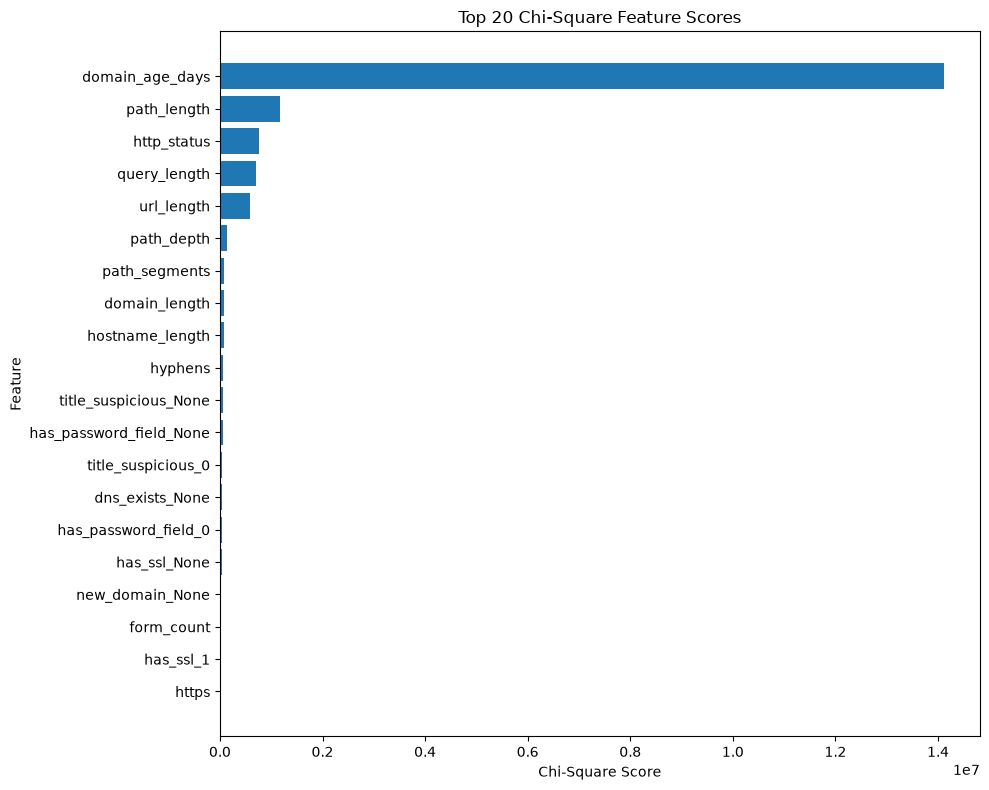

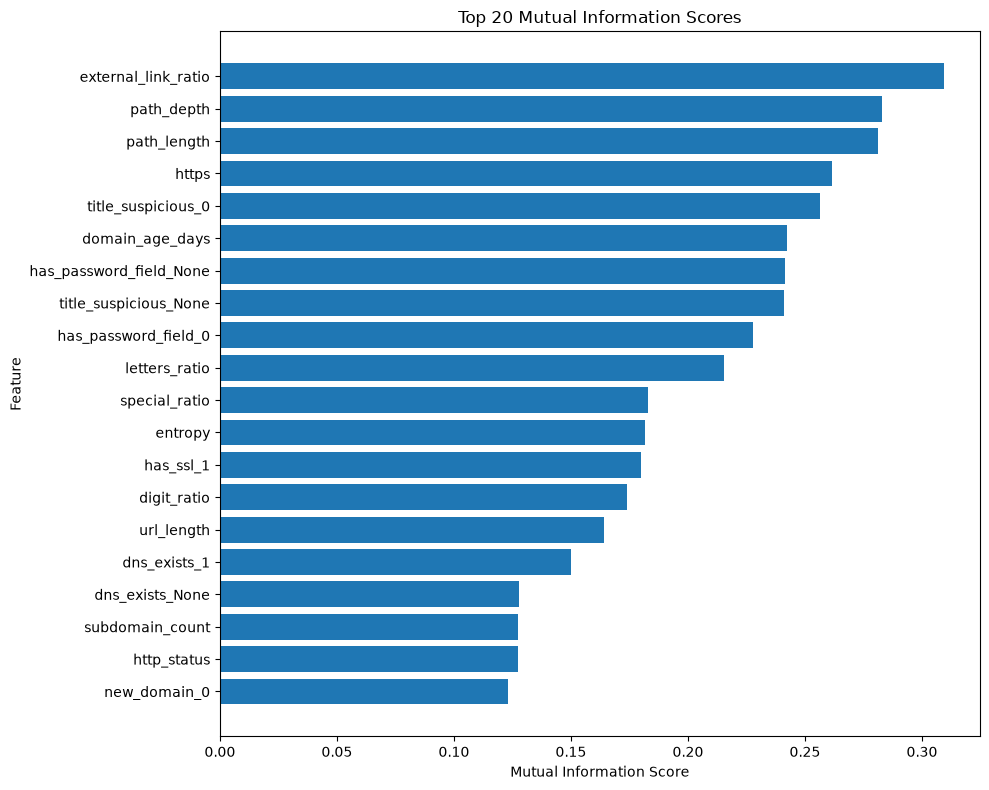

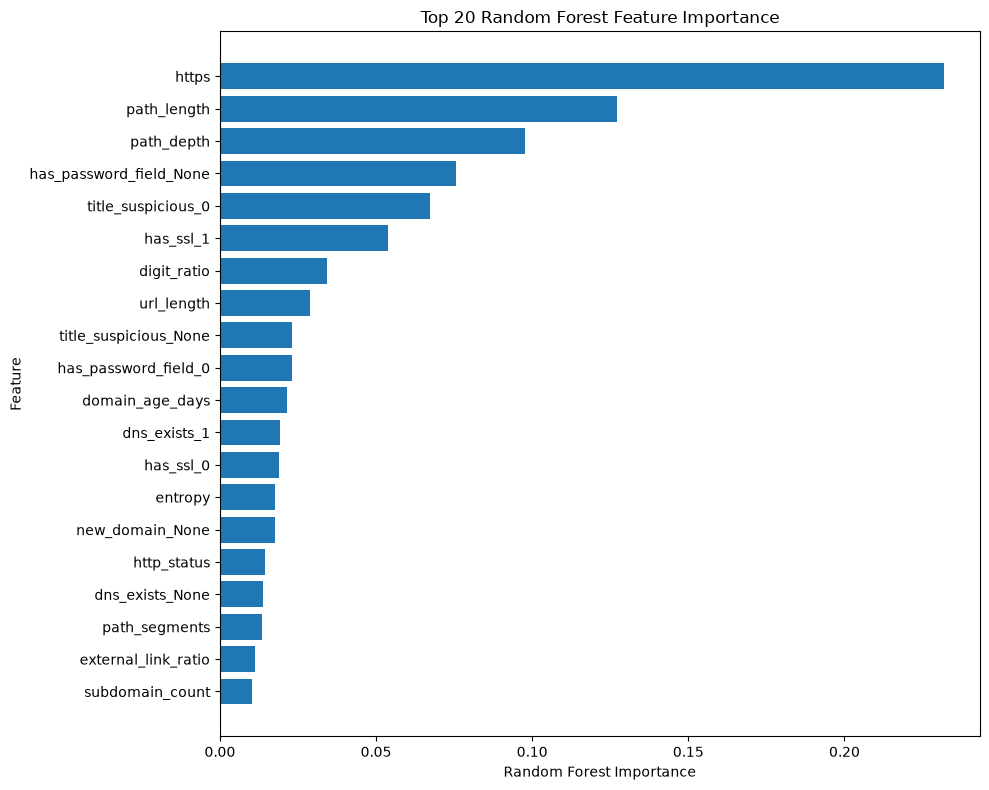

In [356]:
import matplotlib.pyplot as plt

# Store the feature selection
# results and corresponding
# score column names.

feature_selection_methods = [
    (
        chi2_results,
        "Chi-Square Score",
        "Top 20 Chi-Square Feature Scores"
    ),
    (
        mi_results,
        "Mutual Information Score",
        "Top 20 Mutual Information Scores"
    ),
    (
        rf_results,
        "Random Forest Importance",
        "Top 20 Random Forest Feature Importance"
    )
]

# Generate one figure for
# each feature selection
# method.

for results, score_column, title in feature_selection_methods:

    # Select the top twenty
    # ranked features.

    top_features = (
        results
        .head(20)
        .sort_values(by=score_column)
    )

    # Create the figure.

    plt.figure(figsize=(10, 8))

    plt.barh(
        top_features["Feature"],
        top_features[score_column]
    )

    plt.title(title)
    plt.xlabel(score_column)
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

### Understanding the Output

The three feature importance visualizations provide complementary perspectives on the relevance of the predictor features for phishing website classification.

The **Chi-Square Feature Scores** identify predictor variables that exhibit the strongest statistical association with the target variable. Among all features, **domain_age_days** achieved the highest Chi-Square score, indicating that the age of a domain is one of the strongest indicators for distinguishing legitimate and phishing websites. Several URL structural features, including **path_length**, **url_length**, and **query_length**, also demonstrated strong statistical associations with the target class.

The **Mutual Information** ranking measures the amount of information each feature contributes towards predicting the target variable while capturing both linear and non-linear relationships. Features such as **external_link_ratio**, **path_depth**, **path_length**, **https**, and **domain_age_days** received the highest scores, suggesting that URL structure, hyperlink characteristics, and domain age provide substantial information for phishing detection.

The **Random Forest Feature Importance** ranking evaluates feature relevance based on the reduction of impurity achieved during tree construction. The results indicate that **https**, **path_length**, **path_depth**, **has_password_field_None**, and **title_suspicious_0** contributed most to the classification decisions of the ensemble model. Unlike filter-based approaches, Random Forest considers interactions between features, resulting in a slightly different ranking.

Although the rankings differ across the three feature selection techniques, several predictor variables consistently appear among the highest-ranked features, including **domain_age_days**, **https**, **path_length**, **path_depth**, **url_length**, **has_password_field**, and **title_suspicious**. This consistency demonstrates that these predictors contain strong discriminatory information irrespective of the feature selection method employed.

Overall, the visualizations support the use of the consensus-based feature selection strategy adopted in this study. By retaining features identified as important by multiple techniques, the final feature subset combines the strengths of statistical, information-theoretic, and tree-based feature evaluation methods, providing a robust foundation for subsequent exploratory data analysis and machine learning model development.

### Summary

Three complementary feature selection techniques—Chi-Square, Mutual Information, and Random Forest Feature Importance—were employed to evaluate the predictive relevance of the extracted phishing website features. Although each method ranked features using different evaluation criteria, a substantial level of agreement was observed among the highest-ranked predictors.

To improve the robustness of feature selection, a consensus-based strategy was adopted in which features identified by at least two of the three techniques (Consensus Score ≥ 2) were retained. This process resulted in a final subset of **47 predictor features**, reducing the dimensionality of the dataset while preserving the most informative variables.

The selected feature subset forms the basis for the exploratory data analysis presented in the following chapter and is subsequently used for training and evaluating the machine learning models.

### 4.8 Consensus-Based Feature Selection

Each feature selection technique evaluates predictor importance using a different criterion, which may result in variations in the feature rankings. To improve the reliability of the selected feature subset, a consensus-based feature selection strategy is adopted.

The top 45 ranked features obtained from the Chi-Square test, Mutual Information, and Random Forest Feature Importance are compared. Each feature receives one vote for every method in which it appears within the top 45 ranked features. Consequently, a feature may obtain a consensus score ranging from 0 to 3.

Only features with a consensus score of **3**, indicating that they are ranked within the top 45 by all three feature selection techniques, are selected for the final machine learning dataset. This approach reduces the influence of any single feature selection method and identifies predictors that consistently demonstrate high importance across multiple evaluation criteria.

In [357]:
# Number of top-ranked features
# to consider from each method.

TOP_N = 45

# Select the top-ranked features
# from each feature selection
# technique.

chi2_top = set(
    chi2_results
    .head(TOP_N)["Feature"]
)

mi_top = set(
    mi_results
    .head(TOP_N)["Feature"]
)

rf_top = set(
    rf_results
    .head(TOP_N)["Feature"]
)

# Create a DataFrame containing
# every predictor feature.

consensus_results = pd.DataFrame({
    "Feature": X.columns
})

# Determine whether each feature
# appears in the Top-N list for
# each feature selection method.

consensus_results["Chi-Square"] = (
    consensus_results["Feature"]
    .isin(chi2_top)
    .astype(int)
)

consensus_results["Mutual Information"] = (
    consensus_results["Feature"]
    .isin(mi_top)
    .astype(int)
)

consensus_results["Random Forest"] = (
    consensus_results["Feature"]
    .isin(rf_top)
    .astype(int)
)

# Calculate the consensus score.

consensus_results["Consensus Score"] = (
    consensus_results[
        [
            "Chi-Square",
            "Mutual Information",
            "Random Forest"
        ]
    ]
    .sum(axis=1)
)

# Rank the features according
# to their consensus score.

consensus_results = (
    consensus_results
    .sort_values(
        by=[
            "Consensus Score",
            "Feature"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

display(consensus_results)

,Feature,Chi-Square,Mutual Information,Random Forest,Consensus Score
0,digit_ratio,1,1,1,3
1,dns_exists_1,1,1,1,3
2,dns_exists_None,1,1,1,3
3,dns_ip_count,1,1,1,3
4,domain_age_days,1,1,1,3
5,domain_length,1,1,1,3
6,form_count,1,1,1,3
7,has_password_field_0,1,1,1,3
8,has_password_field_None,1,1,1,3
9,has_ssl_0,1,1,1,3


### 4.9 Final Feature Selection

The consensus scores obtained from the three feature selection techniques were used to determine the final subset of predictor features. To ensure that only consistently important features were retained, a feature was selected if it achieved a **Consensus Score of at least 2**, indicating that it was ranked within the top 45 features by at least two of the three feature selection techniques.

Using this criterion, **47 predictor features** were selected for subsequent machine learning model development. Features with a consensus score of 0 or 1 were excluded, as they were identified as important by at most one feature selection technique and therefore exhibited weaker overall agreement.

The selected feature subset balances dimensionality reduction with information preservation by retaining predictors that consistently demonstrate high importance across multiple evaluation methods.

In [ ]:
# Select features with a
# Consensus Score of at
# least 2.
selected_features = (
    consensus_results.loc[
        consensus_results["Consensus Score"] >= 2,
        "Feature"
    ]
    .tolist()
)

# Display the selected
# features.
print(
    f"Number of Selected Features: "
    f"{len(selected_features)}"
)

display(
    pd.DataFrame({
        "Selected Features": selected_features
    })
)

Number of Selected Features: 47


,Selected Features
0,digit_ratio
1,dns_exists_1
2,dns_exists_None
3,dns_ip_count
4,domain_age_days
5,domain_length
6,form_count
7,has_password_field_0
8,has_password_field_None
9,has_ssl_0
